In [1]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import KNNImputer
from feature_engine.encoding import OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import shap
import os

mpl.rcParams['figure.dpi'] = 150

In [2]:
path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")
data_path = os.listdir(path)[0]
full_path = os.path.join(path, data_path)
print(f"Full Path: {full_path}")

Full Path: C:\Users\ASUS\.cache\kagglehub\datasets\kumarajarshi\life-expectancy-who\versions\1\Life Expectancy Data.csv


In [3]:
df = pd.read_csv(full_path)
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [5]:
new_cols_name = [c.strip() for c in df.columns]
df.columns = new_cols_name

In [6]:
df.shape

(2938, 22)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [8]:
print('Duplicated rows:', df.duplicated().sum())

Duplicated rows: 0


In [9]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [10]:
str_columns = df.select_dtypes(include='object').columns.tolist()
numeric_columns = df.select_dtypes(exclude='object').columns.tolist()

print('String Columns:', str_columns, '\n')
print('Numeric Columns:', numeric_columns)

String Columns: ['Country', 'Status'] 

Numeric Columns: ['Year', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [11]:
for col in str_columns:
    print(f'Column {col}: {df[col].unique()}', '\n')

Column Country: ['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas'
 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin'
 'Bhutan' 'Bolivia (Plurinational State of)' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso'
 'Burundi' "Côte d'Ivoire" 'Cabo Verde' 'Cambodia' 'Cameroon' 'Canada'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'
 'Congo' 'Cook Islands' 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus' 'Czechia'
 "Democratic People's Republic of Korea"
 'Democratic Republic of the Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea'
 'Eritrea' 'Estonia' 'Ethiopia' 'Fiji' 'Finland' 'France' 'Gabon' 'Gambia'
 'Georgia' 'Germany' 'Ghana' 'Greece' 'Grenada' 'Guatemala' 'Guinea'
 'Guinea-Bissau' 'Guyana' 'Haiti' 'Honduras' 'Hungary' 'Iceland' 'India'
 'Indonesia' 'Iran (Islam

In [12]:
LABELS_FONT_SIZE = 10
TITLE_FONT_SIZE = 12
SUP_TITLE_FONT_SIZE = 20
FONT_WEIGHT = 'bold'
CMAP = 'PiYG'

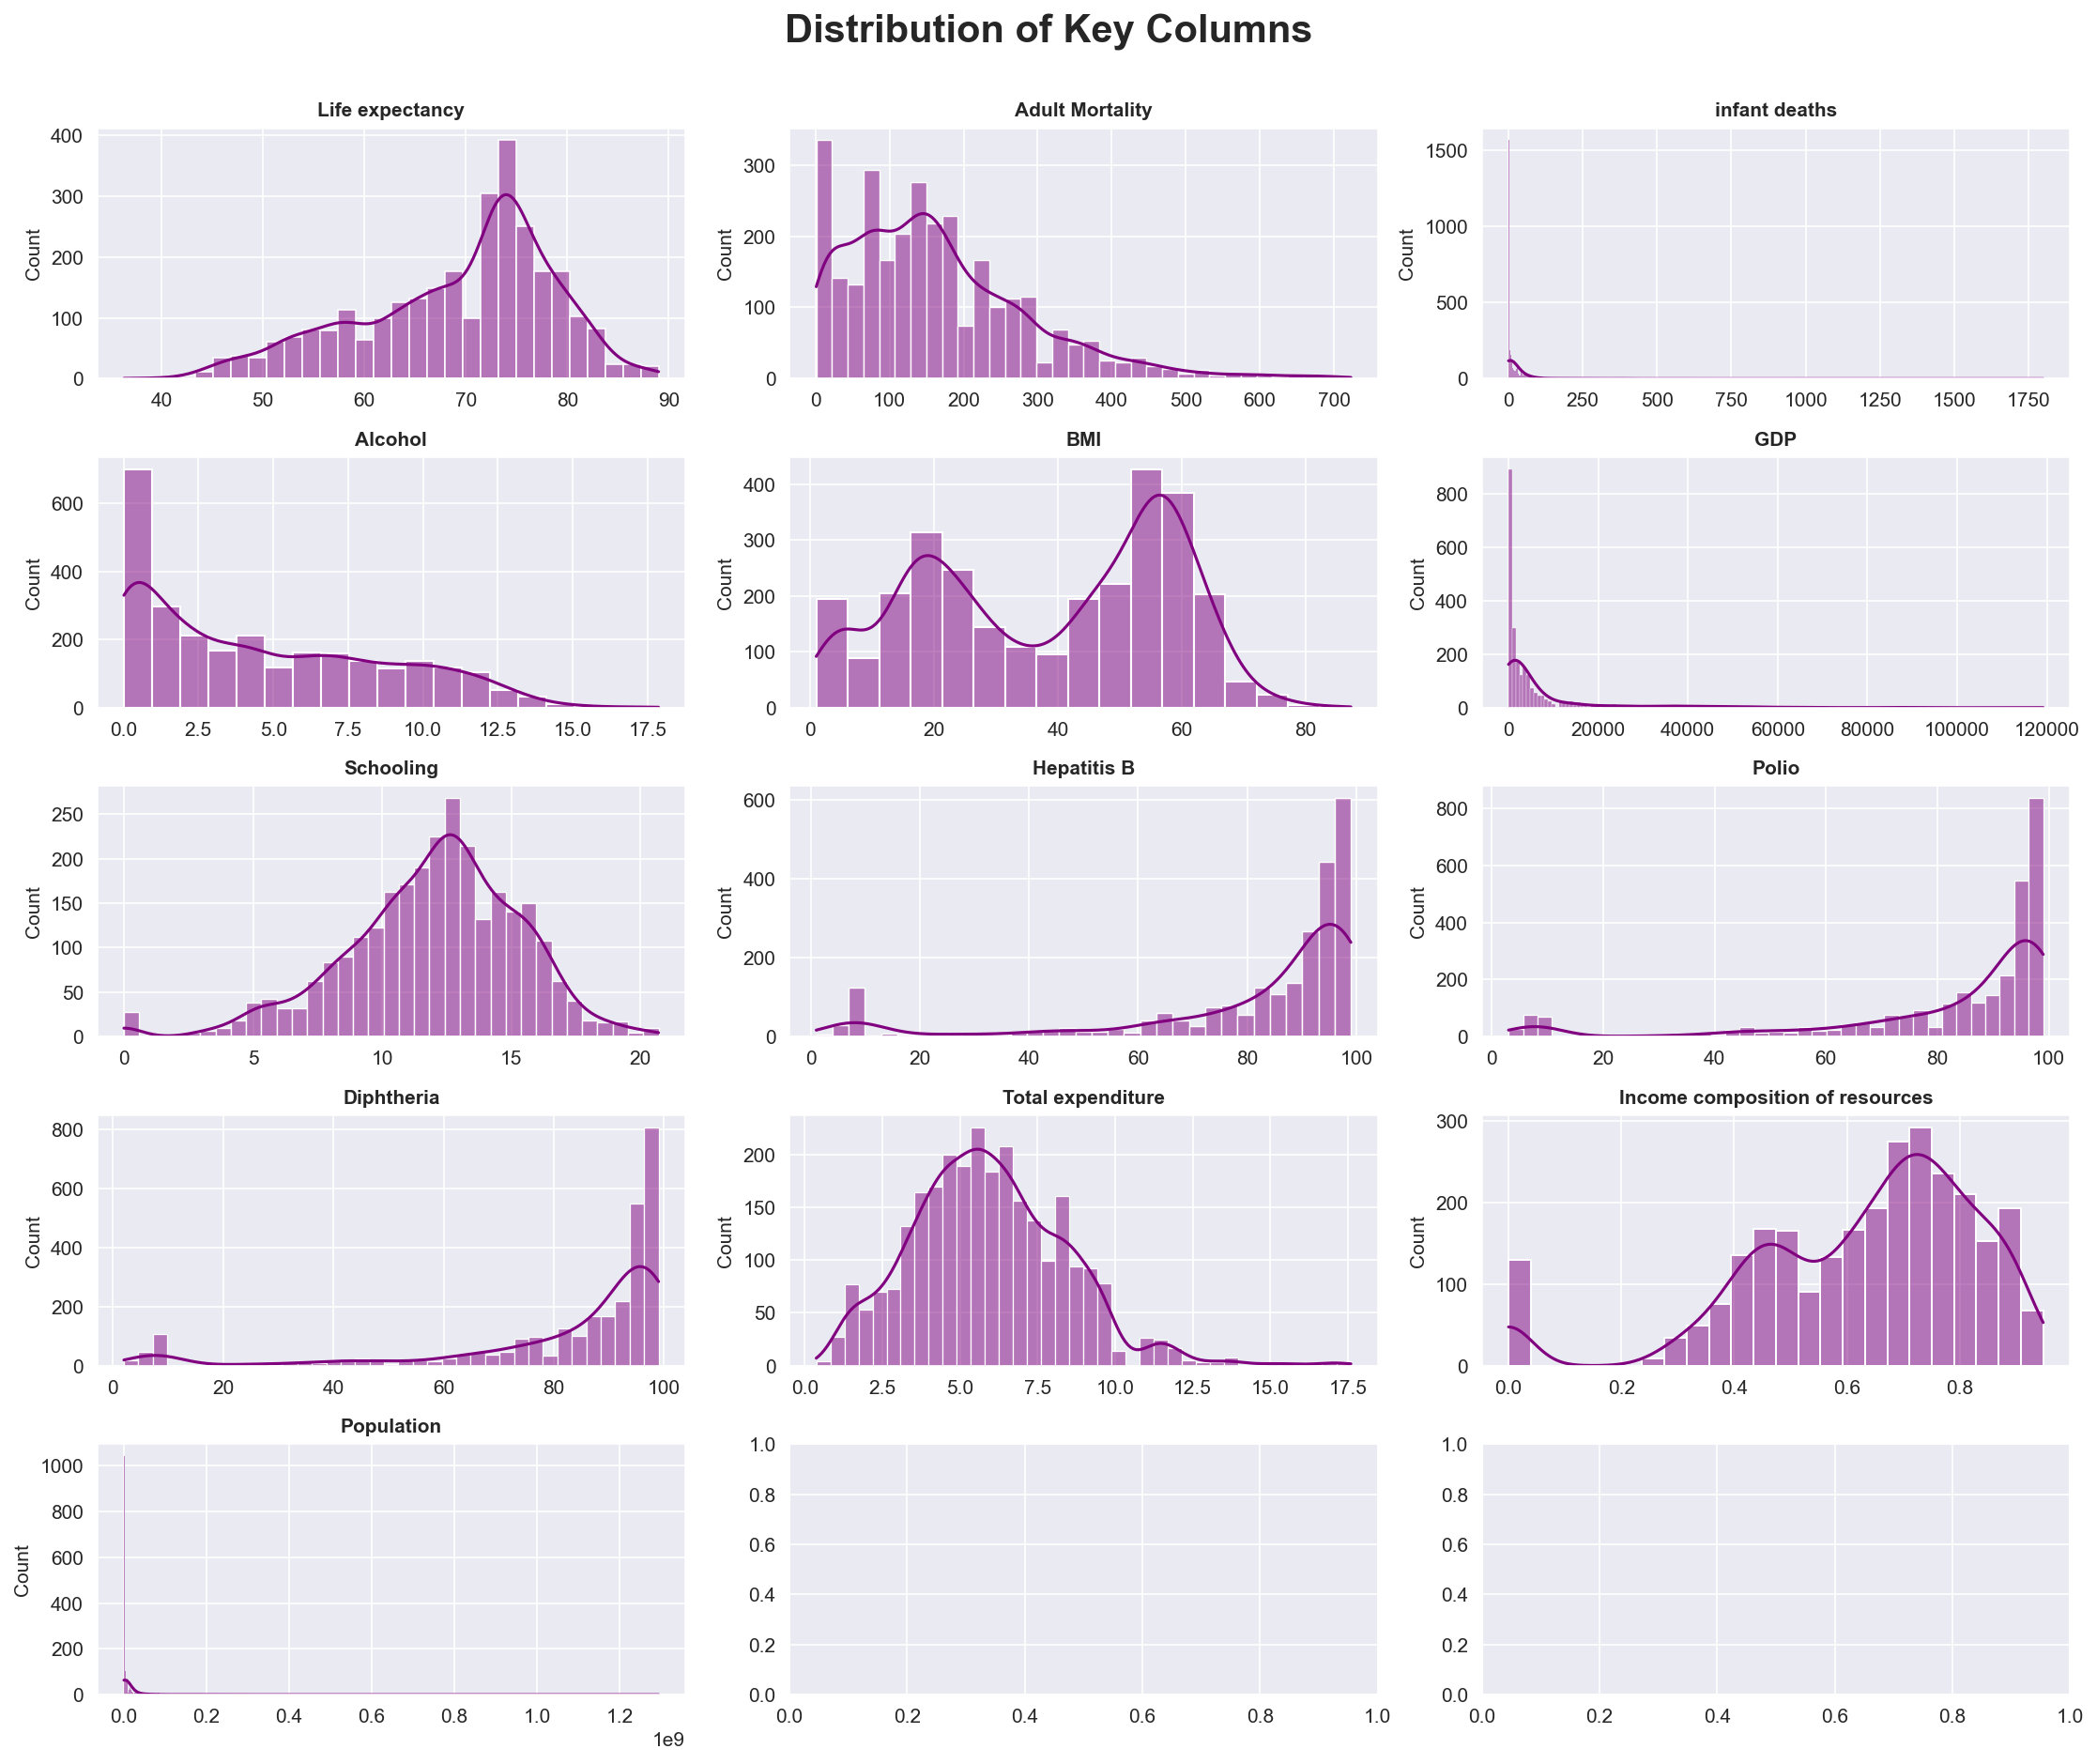

In [13]:
core_vars = [
    'Life expectancy', 'Adult Mortality', 'infant deaths',
    'Alcohol', 'BMI', 'GDP', 'Schooling', 
    'Hepatitis B', 'Polio', 'Diphtheria',
    'Total expenditure', 'Income composition of resources',
    'Population'
]

fig, axes = plt.subplots(5, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(core_vars):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='Purple')
    axes[i].set_title(f'{col.strip()}', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.suptitle('Distribution of Key Columns', y=1.04, fontsize=SUP_TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.show()

In [14]:
null_values = (df.isnull().mean()
               .reset_index()
               .rename(columns={0: 'avg', 'index': 'column'})
               .sort_values(by='avg', ascending=False)
               .query('avg > 0'))

print("Initial missing values:")
print(null_values)

columns_to_fill = null_values.query('0 < avg <= 0.1')['column'].tolist()

for col in columns_to_fill:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print(f"\nFilled {len(columns_to_fill)} columns with <10% missing")

still_remaining = df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
print("\nRemaining missing values:")
print(still_remaining)

if not still_remaining.empty:
    knn_imputer = KNNImputer(n_neighbors=5)
    df[still_remaining.index] = knn_imputer.fit_transform(df[still_remaining.index])

final_null = df.isnull().sum().sum()
print(f"\nTotal missing values after imputation: {final_null}")

Initial missing values:
                             column       avg
17                       Population  0.221920
8                       Hepatitis B  0.188223
16                              GDP  0.152485
13                Total expenditure  0.076923
6                           Alcohol  0.066031
20  Income composition of resources  0.056841
21                        Schooling  0.055480
19               thinness 5-9 years  0.011572
18             thinness  1-19 years  0.011572
10                              BMI  0.011572
12                            Polio  0.006467
14                       Diphtheria  0.006467
3                   Life expectancy  0.003404
4                   Adult Mortality  0.003404

Filled 11 columns with <10% missing

Remaining missing values:
Population     652
Hepatitis B    553
GDP            448
dtype: int64

Total missing values after imputation: 0


## Training Predictive Model

In [15]:
ohe = OneHotEncoder(variables=['Status'], drop_last_binary=True)
df = ohe.fit_transform(df)

X = df.drop(columns=['Year', 'Country', 'Life expectancy'])
y = df['Life expectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
rf = RandomForestRegressor(random_state=42)

params_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2'],
    'max_samples': uniform(0.6, 0.4),
    'criterion': ['squared_error', 'absolute_error']
}


random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

random_search.fit(X_train, y_train)
print('Best Parameters:', random_search.best_params_)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f'Root Mean Squared Error: {rmse}')
print(f'R2 Score: {r2}')

Best Parameters: {'criterion': 'squared_error', 'max_depth': None, 'max_features': 'sqrt', 'max_samples': 0.9990961940195767, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 229}
Root Mean Squared Error: 1.6567391504663644
R2 Score: 0.9683296636164068


In [17]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

In [18]:
def draw_shap_plot(variables, color, shape=(1, 1), figsize=(10, 10), sup_title=''):
    fig, axes = plt.subplots(nrows=shape[0], ncols=shape[1], figsize=figsize)
    axes = axes.flatten()
    
    for i, var in enumerate(variables):
        shap.dependence_plot(
            var,
            shap_values,
            X_test,
            ax=axes[i],
            show=False,
            alpha=0.5,
            interaction_index=None,
            color=color
        )
        axes[i].set_title(f'{var}', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
        axes[i].set_ylabel('SHAP value \n(Life Expectancy)', fontsize=LABELS_FONT_SIZE)

    plt.suptitle(sup_title, 
                 fontsize=SUP_TITLE_FONT_SIZE, fontweight=FONT_WEIGHT, y=1.02)
    plt.tight_layout()
    plt.show()

## Research Questions

1. What is the impact of Immunization coverage on life Expectancy?
2. How does Infant and Adult mortality rates affect life expectancy?
3. Does Life Expectancy has positive or negative correlation with eating habits, lifestyle, exercise, smoking, drinking alcohol etc.
4. Do densely populated countries tend to have lower life expectancy?
5. Does various predicting factors which has been chosen initially really affect the Life expectancy? What are the predicting variables actually affecting the life expectancy?

### 1. What is the impact of Immunization coverage on life Expectancy?

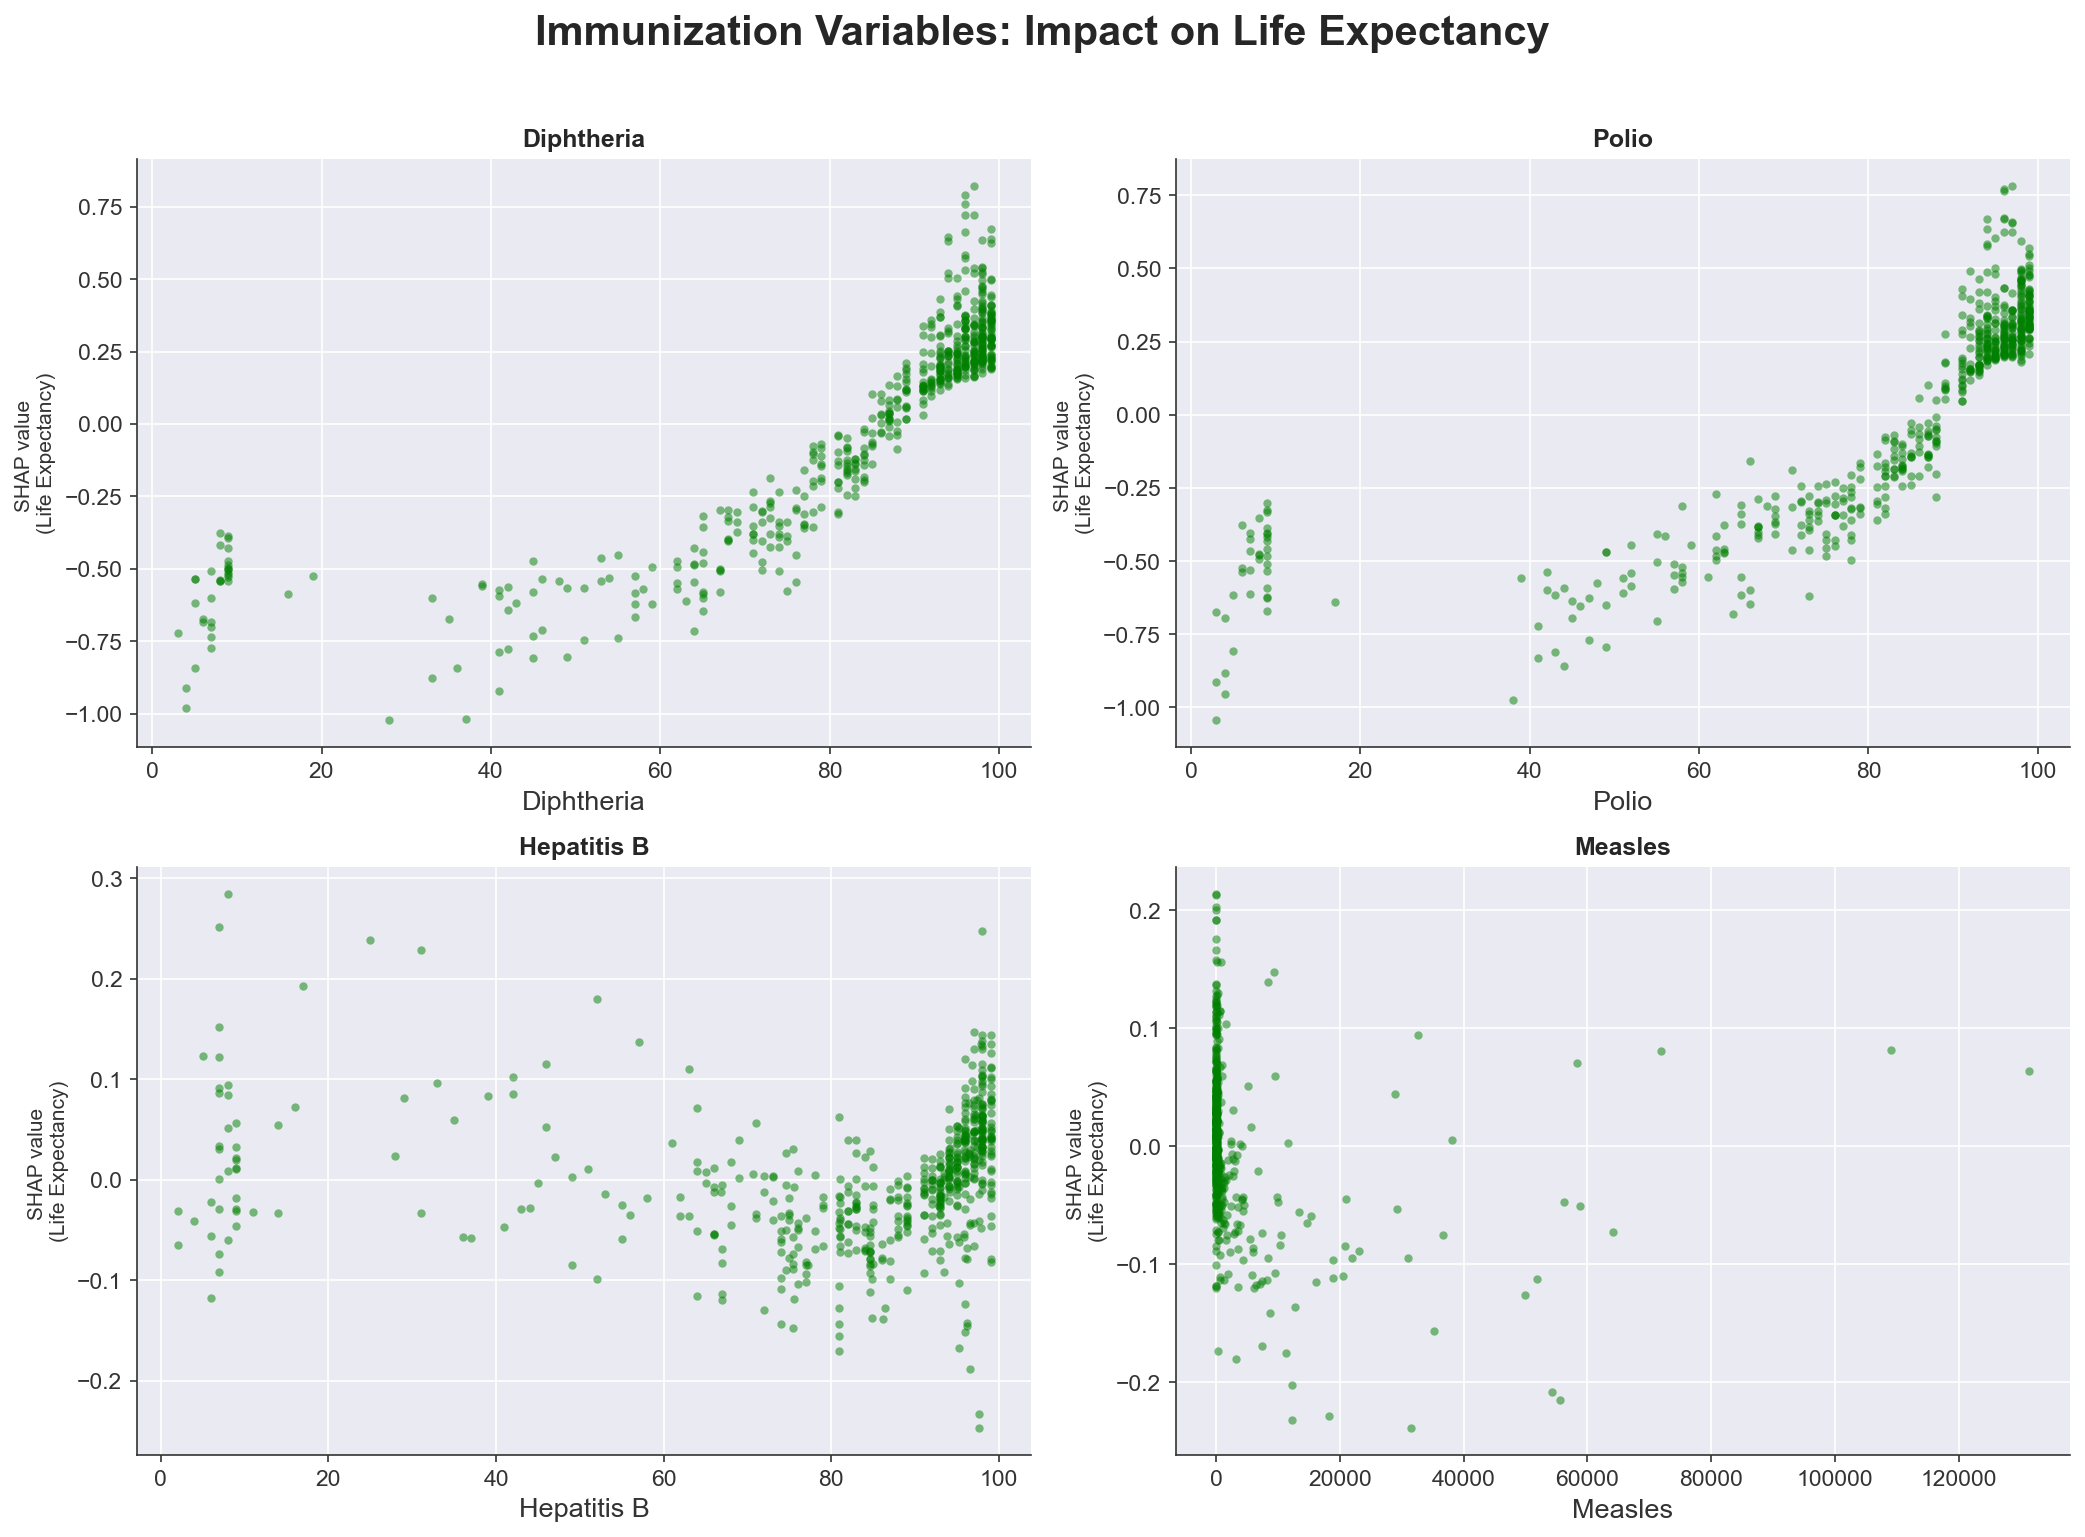

In [19]:
immunization_features = ['Diphtheria', 'Polio', 'Hepatitis B', 'Measles']
draw_shap_plot(
    variables=immunization_features, 
    shape=(2, 2), color='green', 
    figsize=(14, 10), 
    sup_title='Immunization Variables: Impact on Life Expectancy'
)

<p>This chart shows how vaccination programs affect life expectancy. Each panel represents a different vaccine. Countries with higher Diphtheria and Polio coverage (moving right on the chart) tend to have longer life expectancy (moving up). Hepatitis B shows a weaker pattern, while Measles has more variation. The green color indicates stronger effects. Overall, Diphtheria and Polio vaccinations show the clearest connection to longer, healthier lives.</p>

### 2. How does Infant and Adult mortality rates affect life expectancy?

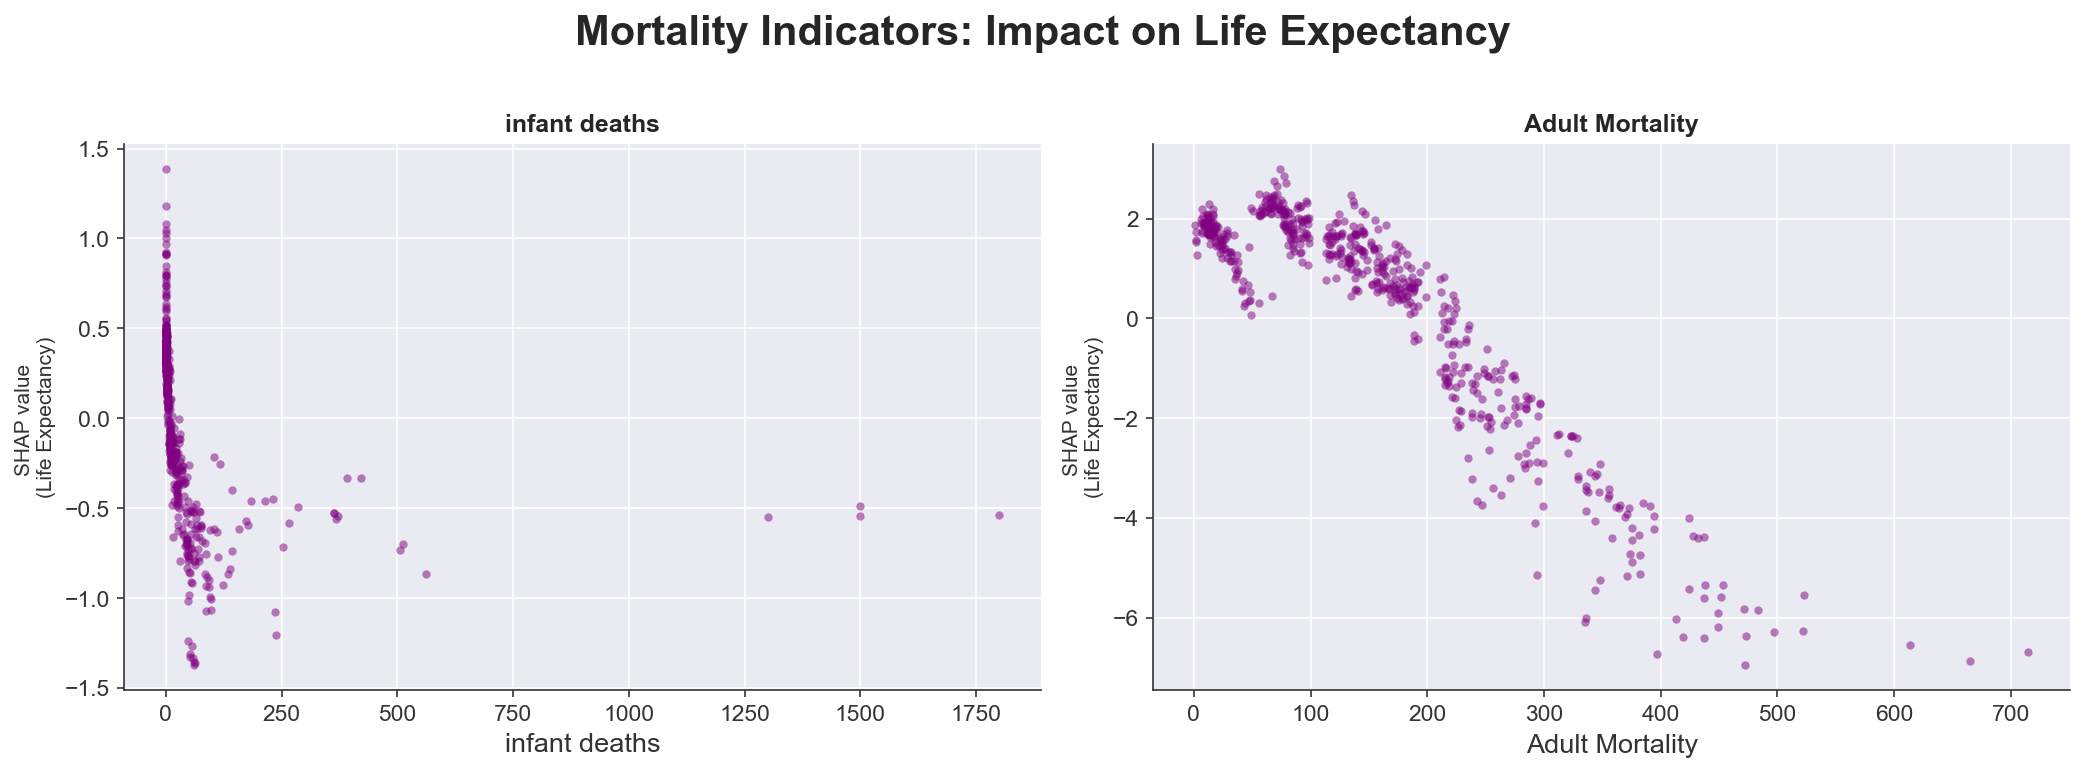

In [20]:
features = ['infant deaths', 'Adult Mortality']
draw_shap_plot(
    variables=features, 
    shape=(1, 2), 
    color='purple', 
    figsize=(14, 5),
    sup_title='Mortality Indicators: Impact on Life Expectancy'
)

<p>This chart shows how infant deaths and adult mortality rates affect life expectancy predictions. The left panel shows infant deaths: countries with very low infant deaths have positive impacts on life expectancy, while higher infant deaths strongly reduce it. The right panel shows adult mortality: as adult mortality increases, life expectancy decreases sharply and consistently. Both patterns are clear—lower mortality rates at any age lead to longer life expectancy, with adult mortality showing an especially strong and direct negative relationship.</p>

### 3. Does Life Expectancy has positive or negative correlation with eating habits, lifestyle, exercise, smoking, drinking alcohol etc.

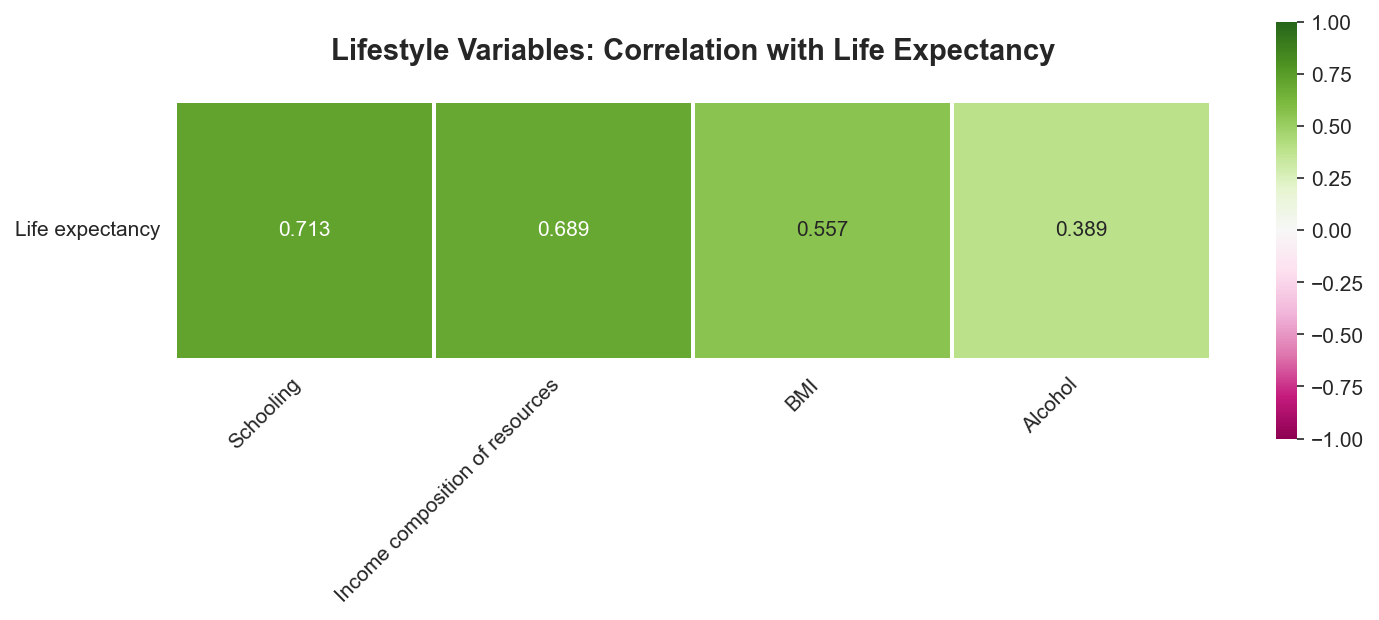

In [21]:
lifestyle_vars = ['BMI', 'Alcohol', 'Income composition of resources', 'Schooling']

lifestyle_correlation = (df[lifestyle_vars + ['Life expectancy']].corr()['Life expectancy']
                .sort_values(ascending=False)
                .drop('Life expectancy'))

corr_df = pd.DataFrame([lifestyle_correlation.values], 
                       columns=lifestyle_correlation.index,
                       index=['Life expectancy'])

plt.figure(figsize=(10, 4))
sns.heatmap(
    corr_df,
    annot=True,
    fmt='.3f',
    cmap=CMAP,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
)

plt.title('Lifestyle Variables: Correlation with Life Expectancy', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<p>
This correlation heatmap examines the relationship between lifestyle-related variables and life expectancy. <strong>Schooling</strong> shows the strongest positive correlation (0.713), indicating that higher education levels are strongly associated with longer life expectancy. <strong>Income composition of resources</strong> follows closely (0.689), reflecting the impact of economic development and resource distribution. <strong>BMI</strong> demonstrates a moderate positive correlation (0.557), suggesting that adequate nutrition (within healthy ranges) contributes to better health outcomes. <strong>Alcohol consumption</strong> shows the weakest correlation (0.389), indicating a more complex relationship that may vary across different consumption levels and contexts. Overall, these findings highlight that <strong>education and economic factors</strong> are more strongly associated with life expectancy than behavioral variables like BMI and alcohol consumption.
</p>

### 4. Do densely populated countries tend to have lower life expectancy?

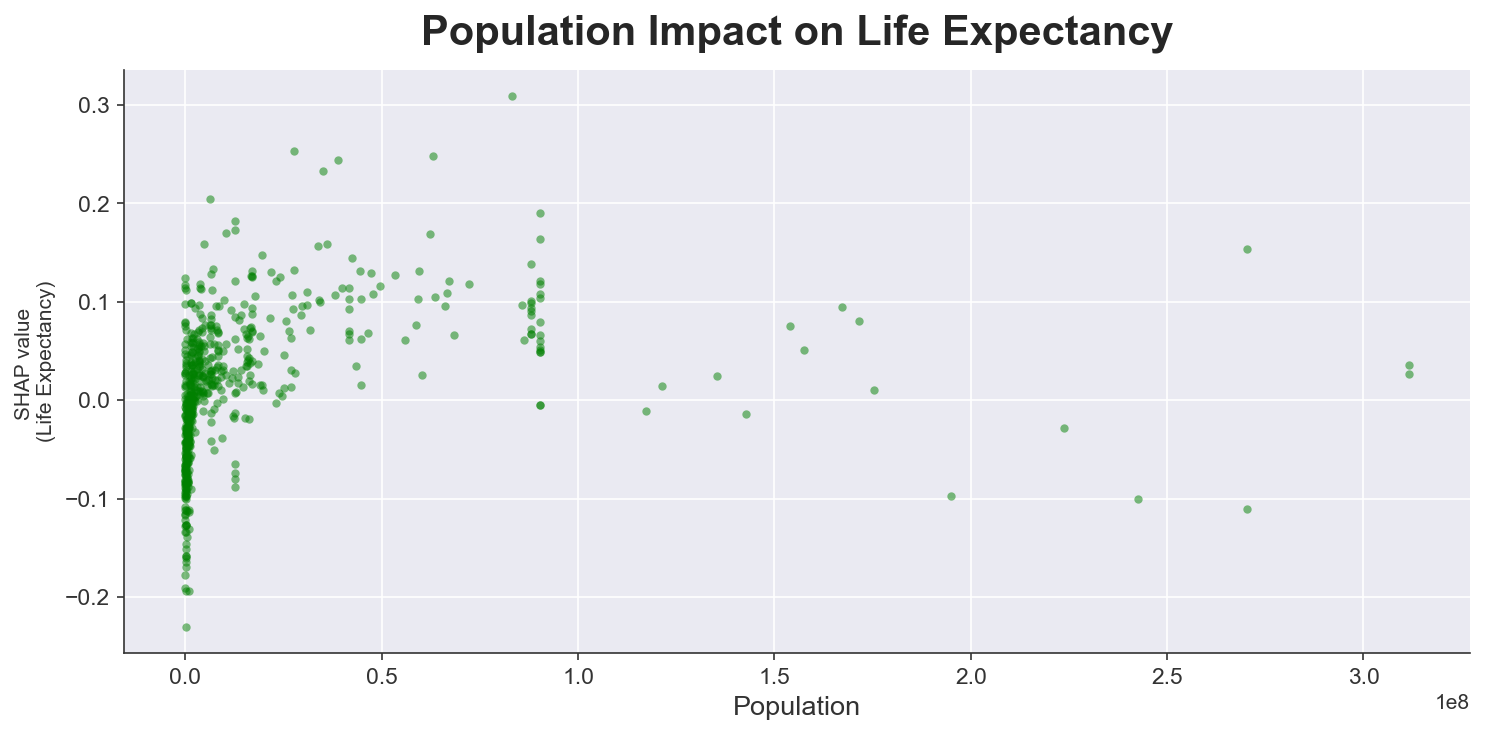

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

mask = X_test['Population'] < 500_000_000

shap.dependence_plot(
    'Population',
    shap_values[mask],
    X_test[mask],
    ax=ax,
    show=False,
    alpha=0.5,
    interaction_index=None,
    color='green'
)

plt.title('Population Impact on Life Expectancy', 
             fontsize=SUP_TITLE_FONT_SIZE, fontweight=FONT_WEIGHT, y=1.02)
plt.ylabel('SHAP value \n(Life Expectancy)', fontsize=LABELS_FONT_SIZE)
plt.tight_layout()
plt.show()

<p>
This SHAP dependence plot shows that population size has a very weak and inconsistent effect on life expectancy predictions. Most countries cluster at lower population values, yet exhibit wide variation in SHAP values, indicating that countries with similar population sizes can have very different life expectancy outcomes.
</p>

### 5. Does various predicting factors which has been chosen initially really affect the Life expectancy? What are the predicting variables actually affecting the life expectancy?

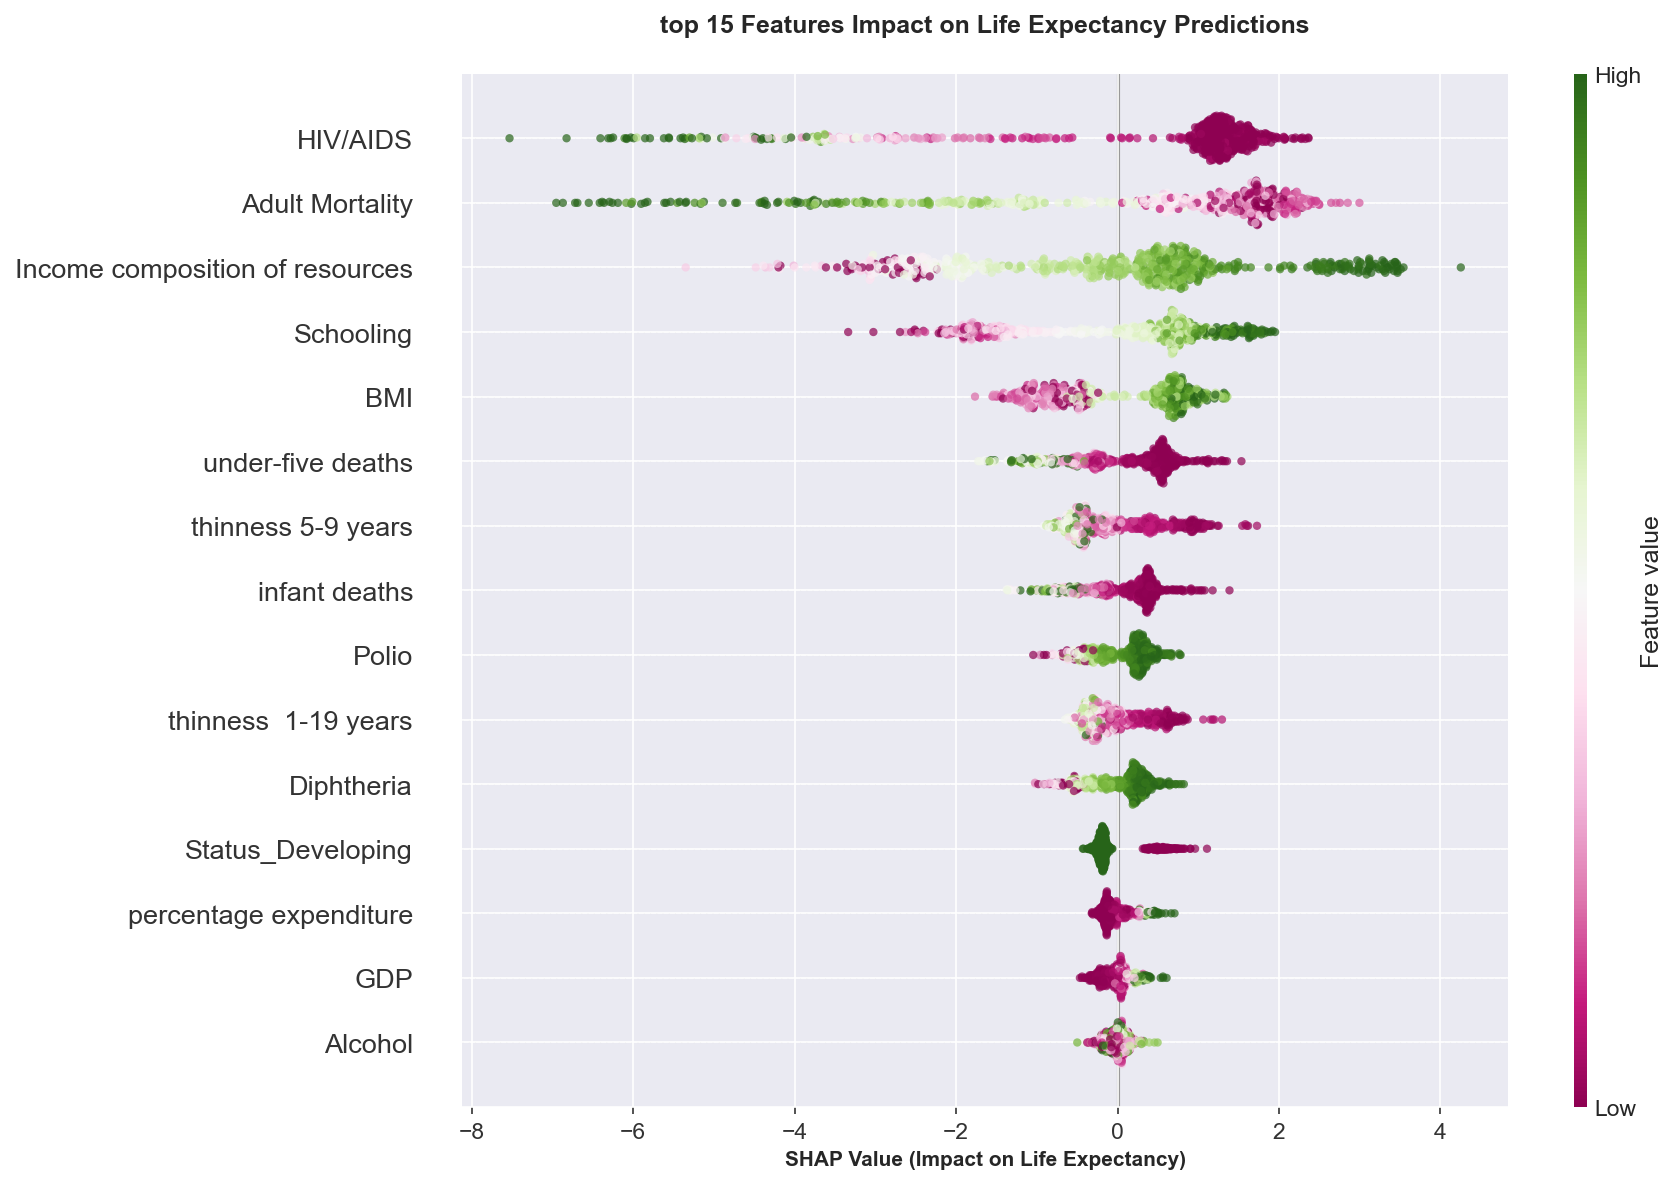

In [23]:
shap.summary_plot(
    shap_values, 
    X_test,
    max_display=15,
    plot_size=(12, 8),
    cmap=CMAP,
    alpha=0.7,
    show=False,
)

plt.title('top 15 Features Impact on Life Expectancy Predictions', fontsize=TITLE_FONT_SIZE, pad=20, fontweight=FONT_WEIGHT)
plt.xlabel('SHAP Value (Impact on Life Expectancy)', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.tight_layout()
plt.show()

<p>This are the top 15 features out of 22 features that has the most effect on <b>Life Expectancy</b>.</p>